### An EDA of our dataset Xeno-Canto A-M

#### DF as is: Describe, Info

In [256]:
from aivian.data import get_dataset_path
import pandas as pd


root = get_dataset_path()
csvs = sorted(root.rglob("*.csv"))
print(csvs)

NA_STRINGS = [
    "Not specified", "not specified", "Not Specified",
    "Not included", "not included", "Not Included",
    "Not applicable", "not applicable", "Not Applicable",
    "Unknown", "unknown", "?", "? m", "?? m", "Unknown m", "unkown m", "- m", " m", "-", "--", "none", "null", "Null", "n.a.", "N.A.",
    "0000-00-00", "?:?", "xx:xx", "am", "pm", ".", "x",
]

df = pd.read_csv(csvs[0], na_values=NA_STRINGS, low_memory=False)
df.info()

[WindowsPath('C:/Users/joano/.cache/kagglehub/datasets/rohanrao/xeno-canto-bird-recordings-extended-a-m/versions/11/train_extended.csv')]
<class 'pandas.DataFrame'>
RangeIndex: 23784 entries, 0 to 23783
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rating            23784 non-null  float64
 1   playback_used     21938 non-null  str    
 2   ebird_code        23784 non-null  str    
 3   channels          23784 non-null  str    
 4   date              23761 non-null  str    
 5   duration          23784 non-null  int64  
 6   filename          23784 non-null  str    
 7   species           23784 non-null  str    
 8   title             23784 non-null  str    
 9   secondary_labels  23784 non-null  str    
 10  bird_seen         21827 non-null  str    
 11  sci_name          23784 non-null  str    
 12  location          23782 non-null  str    
 13  latitude          23359 non-null  float64
 14  samplin

In [257]:
df.describe(include ='all')

,rating,playback_used,ebird_code,channels,date,duration,filename,species,title,secondary_labels,...,background,xc_id,url,country,author,primary_label,longitude,time,recordist,license
count,23784.000000,21938,23784,23784,23761,23784.000000,23784,23784,23784,23784,...,11018,23784.000000,23784,23784,23782,23784,23359.000000,22448,23782,23784
unique,NaN,2,259,2,3696,NaN,23784,259,23784,6464,...,6463,NaN,23784,103,1486,259,NaN,1863,1486,4
top,NaN,no,redcro,2 (stereo),2020-07-19,NaN,XC554809.mp3,Red Crossbill,XC554809 Alder Flycatcher (Empidonax alnorum),[],...,Red-winged Blackbird (Agelaius phoeniceus),NaN,https://www.xeno-canto.org/554809,United States,Richard E. Webster,Loxia curvirostra_Red Crossbill,NaN,08:00,Richard E. Webster,Creative Commons Attribution-NonCommercial-Sha...
freq,NaN,21439,1772,13539,86,NaN,1,1772,1,12766,...,150,NaN,1,13103,1652,1772,NaN,1056,1652,20404
mean,3.256496,NaN,NaN,NaN,NaN,54.498234,NaN,NaN,NaN,NaN,...,NaN,380028.124243,NaN,NaN,NaN,NaN,-70.530775,NaN,NaN,NaN
std,1.217350,NaN,NaN,NaN,NaN,85.703448,NaN,NaN,NaN,NaN,...,NaN,156529.646435,NaN,NaN,NaN,NaN,56.833730,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,245.000000,NaN,NaN,NaN,NaN,-165.405300,NaN,NaN,NaN
25%,2.500000,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,...,NaN,254442.000000,NaN,NaN,NaN,NaN,-112.330500,NaN,NaN,NaN
50%,3.500000,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,...,NaN,393016.000000,NaN,NaN,NaN,NaN,-87.010000,NaN,NaN,NaN
75%,4.000000,NaN,NaN,NaN,NaN,63.000000,NaN,NaN,NaN,NaN,...,NaN,532036.000000,NaN,NaN,NaN,NaN,-49.005100,NaN,NaN,NaN


#### Evaluating by Searching Nan and Alt-Nan (ie: 'Non Applicable's) and Duplicate entries

In [258]:
df.isna().sum()

rating                  0
playback_used        1846
ebird_code              0
channels                0
date                   23
duration                0
filename                0
species                 0
title                   0
secondary_labels        0
bird_seen            1957
sci_name                0
location                2
latitude              425
sampling_rate           0
type                   36
elevation            1324
bitrate_of_mp3          0
file_type               0
background          12766
xc_id                   0
url                     0
country                 0
author                  2
primary_label           0
longitude             425
time                 1336
recordist               2
license                 0
dtype: int64

In [259]:
for col in df.columns:
    n = df[col].nunique(dropna=False)
    print(f"\n{col} ({n} unique)\nNull:{df[col].isna().sum()}")
    print(df[col].value_counts(dropna=False))


rating (11 unique)
Null:0
rating
3.5    4920
4.0    4782
3.0    3611
2.5    2675
4.5    2150
5.0    2061
0.0    1413
2.0    1187
1.5     612
1.0     251
0.5     122
Name: count, dtype: int64

playback_used (3 unique)
Null:1846
playback_used
no     21439
NaN     1846
yes      499
Name: count, dtype: int64

ebird_code (259 unique)
Null:0
ebird_code
redcro     1772
houspa     1216
houwre      984
comrav      889
eursta      694
           ... 
norhar2       1
rinduc        1
rufgro        1
shshaw        1
swahaw        1
Name: count, Length: 259, dtype: int64

channels (2 unique)
Null:0
channels
2 (stereo)    13539
1 (mono)      10245
Name: count, dtype: int64

date (3697 unique)
Null:23
date
2020-07-19    86
2020-05-21    74
2020-04-25    69
2018-06-08    66
2020-04-19    60
              ..
2016-09-03     1
2010-08-05     1
2009-04-25     1
2011-06-19     1
2000-10-20     1
Name: count, Length: 3697, dtype: int64

duration (551 unique)
Null:0
duration
10     542
6      456
12     445


In [260]:
dupes = df[df.duplicated(keep=False)]
print(len(dupes), "rows involved in exact duplication")
dupes

0 rows involved in exact duplication


,rating,playback_used,ebird_code,channels,date,duration,filename,species,title,secondary_labels,...,background,xc_id,url,country,author,primary_label,longitude,time,recordist,license


#### Further evaluationg data before converting to graphable values
Goind down the list of our columns from .isna().sum()
- Rating, 0-5, most likely not going to be used except to train the model in stages. ie: training and test
with rate 5 recordings and then 4, 3, 2, 1
    - Cell below is an example of a rating 0 recording
    - Rating zero means the recording was never officially rated on xeno-canto
- Playback_used Nan entries only accounts for 8% of the column's data
    - You can hear people making bird calls in the background to provoke the bird, though the bird comes out much clearer
    - rating is also 0.0
    - Unlikely but not impossible that a conflicting bird species cry was used
    - ie: House Sparrows vs Eastern Bluebird
- Ebird_code refers to an alphanumeric abbreviation of a bird's species
- Channels refer to Mono or Stereo
    - Cell below fetches the first instance of 
- Date is formatted as Year-month-date of when the recording was captured in the field
- Duration is the length of the recording in seconds
- Filename is the name of the mp3 file
- Species is the name of the bird Species:
    - ie: Alder Flycatcher
- Title is a collection of the Filename(sans .mp3) Species name and Scientific name
    - ie: XC554809 Alder Flycatcher (Empidonax alnorum)
- Labels (primary and Secondary) 
    - Two bird species possibly one bird that was intended to be viewed and a second call that could be heard in the recording
    - Also possibly one main species and a sub species of birds
    - from Kaggle BirdCall Clef 2021 competition forum: "Typically is the primary label is the bird that you hear loudest / most often, but it could just be the one that the author was most interested in / was watching at the time. Secondary labels are moderately sparse and indicate other birds that can also be heard in the recording."
- Bird seen is denoted with yes or no
- Scientific name is what it is
- Location is usually denoted with City Name (maybe a note ie: "near leamington"), County, State
- Country is it's own thing not included in Location
- Latitude and longitude as are
- Sampling_rate -- str hertz -- "the number of times per second an analog sound wave is measured and converted into a digital value"
    - this may vary depending on background noise, extended periods of silence
    - and the variation of purpose in bird calls
    - ie: territorial display, mating, nesting, etc
- Type is a description of the call itself and can greatly vary, may include age, gender, purpose:
    - ie:
        - "call"
        - "adult, call, male"
        - adult, begging call, hatchling or nestling, sex uncertain, song
        - adult, call, colony sounds, female, male, song
        - Chip, call
        - 3 part trill, song
        - "Tchik", call, female, male
- Elevation is height above sea level where audio was captured (str type, honestly could've been an int)
    - ie: 70m
- Bitrate_of_mp3 (according to gemini) -- Also a str column (╯°□°)╯︵ ┻━┻
    - "The bit rate of an MP3 is the amount of digital audio data processed per second, usually measured in kilobits per second (kbps)"
    - "96 kbps to 128 kbps: Low to basic quality. It works for voice recordings or saving space, but music can sound thin or fuzzy"
- File_type - a str type -- all of these are mp3 with no Nan values
    - will drop this as file type has no effect on predictions
- Background -- functions the same as secondary labels but may include the species name and scientific name
    - or empty string
    - or a list separated by a semicolon
    - ie: 
    - or: Great Crested Flycatcher (Myiarchus crinitus); Indigo Bunting (Passerina cyanea); Common Yellowthroat (Geothlypis trichas); Eastern Wood-Pewee (Contopus virens); Northern Cardinal (Cardinalis cardinalis); Carolina Wren (Thryothorus ludovicianus)
- xc_id -- unique xeno canto id - also the file name and extension for url. Ie: 554809
- url -- the link to bird recording. Ie: https://www.xeno-canto.org/554809
- Country - country where the recording was captured
    - unique values section indicate they may also be labeled as Null, will update Nan type acceptance in pandas.read_csv
- Author - may be Null but includes the first and last name of "the user account that uploaded and published the recording file to the database"
- Longitude - as is
- Time - local time of day the recording was captured - str representation 
    - ex: 
        - 7:00
        - 09:44:21
        - 13:28:41 
- Recordist - different from the author (may also be Null) - the name of the person that actually captured the audio
- License 4 types:
    - Creative Commons Attribution-NonCommercial-ShareAlike 3.0 or 4.0
    - Creative Commons Attribution-ShareAlike 3.0 or 4.0

##### Some noteable data/examples to better visualize column purpose

In [261]:
df[df['duration'] == 0].iloc[0]

rating                                                            2.0
playback_used                                                      no
ebird_code                                                     amepip
channels                                                     1 (mono)
date                                                       2016-02-02
duration                                                            0
filename                                                 XC412953.mp3
species                                            Buff-bellied Pipit
title                  XC412953 Buff-bellied Pipit (Anthus rubescens)
secondary_labels                                                   []
bird_seen                                                         yes
sci_name                                             Anthus rubescens
location                       Jersey City, Hudson County, New Jersey
latitude                                                      40.7033
sampling_rate       

In [262]:
#Zero rating audio
df[df['rating'] == 0].iloc[0]


rating                                                            0.0
playback_used                                                      no
ebird_code                                                     aldfly
channels                                                   2 (stereo)
date                                                       2019-06-11
duration                                                           49
filename                                                 XC554809.mp3
species                                              Alder Flycatcher
title                   XC554809 Alder Flycatcher (Empidonax alnorum)
secondary_labels                                                   []
bird_seen                                                         yes
sci_name                                            Empidonax alnorum
location                           Wasilla, Matanuska-Susitna, Alaska
latitude                                                      61.6841
sampling_rate       

In [263]:
#playback_used == yes
df[df['playback_used'] == 'yes'].iloc[0]


rating                                                            0.0
playback_used                                                     yes
ebird_code                                                     aldfly
channels                                                   2 (stereo)
date                                                       2020-04-05
duration                                                           35
filename                                                 XC544552.mp3
species                                              Alder Flycatcher
title                   XC544552 Alder Flycatcher (Empidonax alnorum)
secondary_labels                                                   []
bird_seen                                                         yes
sci_name                                            Empidonax alnorum
location                                     Mana Dulce, Cundinamarca
latitude                                                        4.351
sampling_rate       

In [264]:
#mono --> 1 (mono) or stereo --> 2 (stereo)
df[df['channels'] == '2 (stereo)'].iloc[0]


rating                                                            0.0
playback_used                                                      no
ebird_code                                                     aldfly
channels                                                   2 (stereo)
date                                                       2019-06-11
duration                                                           49
filename                                                 XC554809.mp3
species                                              Alder Flycatcher
title                   XC554809 Alder Flycatcher (Empidonax alnorum)
secondary_labels                                                   []
bird_seen                                                         yes
sci_name                                            Empidonax alnorum
location                           Wasilla, Matanuska-Susitna, Alaska
latitude                                                      61.6841
sampling_rate       

In [265]:
#secondary_labels vs primary_labels
df[df['secondary_labels'] == "[]"].iloc[0]

rating                                                            0.0
playback_used                                                      no
ebird_code                                                     aldfly
channels                                                   2 (stereo)
date                                                       2019-06-11
duration                                                           49
filename                                                 XC554809.mp3
species                                              Alder Flycatcher
title                   XC554809 Alder Flycatcher (Empidonax alnorum)
secondary_labels                                                   []
bird_seen                                                         yes
sci_name                                            Empidonax alnorum
location                           Wasilla, Matanuska-Susitna, Alaska
latitude                                                      61.6841
sampling_rate       

#### Transforming the data we want to graph

In [266]:
#here we're going to drop a couple columns and sace it to our drop_df
#ebird code isn't necessary to determine the species of our bird
drop_df = df.drop(['ebird_code'], axis=1, inplace=False)

#title fulfills the role of multiple columns but is a little more difficult to normalize

#we're keeping background becuase a Nan background doesn't necessarily mean Nan secondary labels 
#   but we'll graph that for better understanding (also there's 12000+ NaN backgrounds but only 1900+ NaN sec_labels)

#we don't care for our targets right now, and can also drop the same from our test df
#   but we'll keep species just for readability
#   Targets: species, sci_name, xc_id, ebird_code, etc

#we don't need author, and we're not going to tell our model predict a bird species based on recordist
#   (which may or may not usually be a local volunteer)
#   but what we could do is possibly use the name if we happen to notice our
#   recording is similar to theirs/if they happen to have a larger number of recordings
#   in specific countries, chasing a specific bird

#we don't need recording license
#file type is the same
drop_list=['title', 'sci_name', 'xc_id', 'url', 'author', 'license', 'file_type']
for column in drop_list:
    drop_df.drop([column],axis=1,inplace=True)
drop_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23784 entries, 0 to 23783
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rating            23784 non-null  float64
 1   playback_used     21938 non-null  str    
 2   channels          23784 non-null  str    
 3   date              23761 non-null  str    
 4   duration          23784 non-null  int64  
 5   filename          23784 non-null  str    
 6   species           23784 non-null  str    
 7   secondary_labels  23784 non-null  str    
 8   bird_seen         21827 non-null  str    
 9   location          23782 non-null  str    
 10  latitude          23359 non-null  float64
 11  sampling_rate     23784 non-null  str    
 12  type              23748 non-null  str    
 13  elevation         22460 non-null  str    
 14  bitrate_of_mp3    23784 non-null  str    
 15  background        11018 non-null  str    
 16  country           23784 non-null  str    
 17  prim

In [267]:
#in our duplicates and nan section we already confirmed the only unique values were 
# yes, no, or Nan for our bird_seen and playback_used column
yes_no = {"yes": 1, "no": 0}
for col in ["bird_seen", "playback_used"]:
    drop_df[col] = df[col].map(yes_no).astype("Int64")

print(drop_df["bird_seen"].value_counts(dropna=False))
drop_df["playback_used"].value_counts(dropna=False)

bird_seen
1       15890
0        5937
<NA>     1957
Name: count, dtype: Int64


playback_used
0       21439
<NA>     1846
1         499
Name: count, dtype: Int64

In [268]:
# rating 0 = never rated on xeno-canto, not "worst quality" -> NaN
import numpy as np
drop_df["rating"] = df["rating"].replace(0.0, np.nan)

In [269]:
#Extracting 1 and 2 from mono and stereo as well as hz and bpm
for col in ["channels", "sampling_rate", "bitrate_of_mp3"]:
    drop_df[col] = df[col].str.extract(r"^(\d+)", expand=False).astype("Int64")


##### Parsing and Transforming Elevation to account for odd malformations

In [270]:
odd_elevation = df.loc[df["elevation"].notna() & ~df["elevation"].str.fullmatch(r"-?\d+(\.\d+)?\s*m"), "elevation"]
odd_elevation.value_counts()

elevation
2750-3250 m              3
unknown m                2
1650-1900 m              2
1,105 m m                2
363.364838 m m           2
391.798309 m m           2
~200 m                   1
1,885 m m                1
5.2 meters m             1
1,360 m m                1
3,000 m                  1
3100 - 3300  m           1
aproximadamente 300 m    1
910.747.375 m            1
564.676.941 m            1
566.528.198 m            1
250 m m                  1
3-4 m                    1
1900m m                  1
Name: count, dtype: int64

In [271]:
odd_elevations = ["564.676.941 m", "566.528.198 m", "910.747.375 m",
            "1,105 m m", "1,885 m m", "1,360 m m", "3,000 m"]
df.loc[df["elevation"].isin(odd_elevations),
       ["xc_id", "location", "country", "latitude", "longitude", "elevation"]]

,xc_id,location,country,latitude,longitude,elevation
2429,169448,Lathrop State Park,United States,NaN,NaN,"1,885 m m"
5823,168035,"Higbee, Colorado",United States,NaN,NaN,"1,360 m m"
7018,167551,"Ward, Colorado",United States,NaN,NaN,"3,000 m"
14975,167881,"Lamar, Colorado",United States,NaN,NaN,"1,105 m m"
15117,434572,"Dugout Wells, Big Bend National Park, TX",United States,29.271,-103.135,910.747.375 m
15119,434570,"Rio Grand Village Store, Big Bend National Par...",United States,29.183,-102.961,564.676.941 m
15136,434569,"Rio Grand Village Store, Big Bend National Par...",United States,29.181,-102.961,566.528.198 m
22569,167879,"Lamar, Colorado",United States,NaN,NaN,"1,105 m m"


In [272]:
import re
import numpy as np

# Claude Generated - Human Reviewed
# Cleaning varied/malformed elevation
#   "1,105 m m" becomes 1105
#   "564.676.941 m" -> 564.676941 mangled decimal point -- confirmed location in United States and not UK/EU regional formating
#   "2750-3250 m"   -> 3000       ranges become the midpoint
#   "~200 m", "aproximadamente 300 m", "1900m m" -> the number
#   "? m", "Unknown m", "- m", " m" -> NaN (no usable number) -- Also added in NAN_STRINGS but kept here to catch stray strings
def parse_elevation(s):
    """Elevation text -> meters (float), or NaN when there's no usable number."""
    if pd.isna(s):
        return np.nan
    s = s.replace(",", "")                                    # '1,105' -> '1105'

    # Forcing claude to reevaluate naming conventions - multi seems to have been meant for multiple decimal points
    multi = re.search(r"(\d+)\.(\d+(?:\.\d+)+)", s)           # '564.676.941' -> '564.676941'
    if multi:
        s = s.replace(multi.group(0), multi.group(1) + "." + multi.group(2).replace(".", ""))

    #rng to avoid keyword range
    rng = re.search(r"(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)", s)
    if rng:                                                   # '2750-3250' -> 3000 (midpoint)
        return (float(rng.group(1)) + float(rng.group(2))) / 2

    #previously named 'one' to indicate singular num and not a range -- variable renamed to negative for readability
    negative = re.search(r"-?\d+(?:\.\d+)?", s)                    # '-30 m' stays negative
    return float(negative.group()) if negative else np.nan

drop_df["elevation"] = df["elevation"].apply(parse_elevation)

print("elevation missing:", drop_df["elevation"].isna().sum())
drop_df["elevation"].describe()

elevation missing: 1326


count    22458.000000
mean       604.138497
std        793.638968
min      -3670.000000
25%         40.000000
50%        220.000000
75%       1000.000000
max       7760.000000
Name: elevation, dtype: float64

##### Parsing and Transfoming Time to # of Hours after midnight

In [273]:
odd_time = df.loc[df["time"].notna() & drop_df["time"].isna(), "time"]
odd_time.value_counts()

Series([], Name: count, dtype: int64)

In [274]:
# claude generated
# time: '7:00" -> 7.0, "7:30" -> 7.5, "13:28:41" -> 13.47 (decimal hours; seconds dropped)
# handles "7:30 pm", "6.30", "8h30"; #hypothetically a 25:00 would become NaN but 24:15 would wrap

#later added semi-colon after checking nan values with:
#   odd_time = df.loc[df["time"].notna() & drop_df["time"].isna(), "time"]
#   odd_time.value_counts()
parts = df['time'].str.extract(
    r'^\s*0*(\d{1,2})\s*[;:.h]\s*(\d{2})(?::\d{2})?\s*(am|pm)?\s*$', flags=re.IGNORECASE)

#changed h and m to hours and minutes
hours = pd.to_numeric(parts[0], errors='coerce')
minutes = pd.to_numeric(parts[1], errors='coerce')

ampm = parts[2].str.lower()
hours = hours.where(~((ampm == 'pm') & (hours < 12)), hours + 12)   # 7:30 pm -> 19:30
hours = hours.where(~((ampm == 'am') & (hours == 12)), 0)       # 12:15 am -> 00:15


hours = hours.where(hours != 24, 0)

#this is the part where claude removes what it thinks are invalid times
valid = hours.between(0, 23) & minutes.between(0, 59)
drop_df['time'] = (hours + minutes / 60).where(valid).round(2)

print('time missing:', drop_df['time'].isna().sum())
drop_df['time'].describe()

time missing: 1336


count    22448.000000
mean        10.428789
std          4.259052
min          0.000000
25%          7.500000
50%          9.400000
75%         12.500000
max         23.950000
Name: time, dtype: float64

In [275]:
#checking for odd formatting and invalid hours
#prior iterations of checking for odd_time show no instances of 25:00
odd_time = df.loc[df["time"].notna() & drop_df["time"].isna(), "time"]
odd_time.value_counts()

Series([], Name: count, dtype: int64)

##### Renaming Time, Bitrate, and Sampling Rate

In [276]:
drop_df = drop_df.rename(columns={'time':'hours_from_midnight',
                                  'bitrate_of_mp3':'bitrate_bps',
                                  'sampling_rate':'sampling_rate_hz'})
drop_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23784 entries, 0 to 23783
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rating               22371 non-null  float64
 1   playback_used        21938 non-null  Int64  
 2   channels             23784 non-null  Int64  
 3   date                 23761 non-null  str    
 4   duration             23784 non-null  int64  
 5   filename             23784 non-null  str    
 6   species              23784 non-null  str    
 7   secondary_labels     23784 non-null  str    
 8   bird_seen            21827 non-null  Int64  
 9   location             23782 non-null  str    
 10  latitude             23359 non-null  float64
 11  sampling_rate_hz     23784 non-null  Int64  
 12  type                 23748 non-null  str    
 13  elevation            22458 non-null  float64
 14  bitrate_bps          23784 non-null  Int64  
 15  background           11018 non-null  str    
 1

#### Graphing our Data

##### Current Columns:
- rating - 1-5
- playback_used - 1 or 0 (yes or no)
- channels - 1 or 2 (mono or stereo)
- date - string year/month/day
- duration - seconds
- filename - string file name (ie: ebirdcode.filetype)
- species - string species name
- secondary_labels - list of secondary species names
- bird_seen- 1 or 0 (yes or no)
- location - string city, county, state
- lat and long are themselves
- sampling_rate_hz - sound measured per second
- type - call description
- elevation - above or below sea level
- bitrate_bps - much data the audio file uses for each second of sound
- background - usually a list of other birds and sounds that could be heard in the background not necessarily the same as secondary labels
- country - string country
primary_label - the name of the main bird singing
- hours_from_midnight - int
- recordist - name of the person that captured the audio

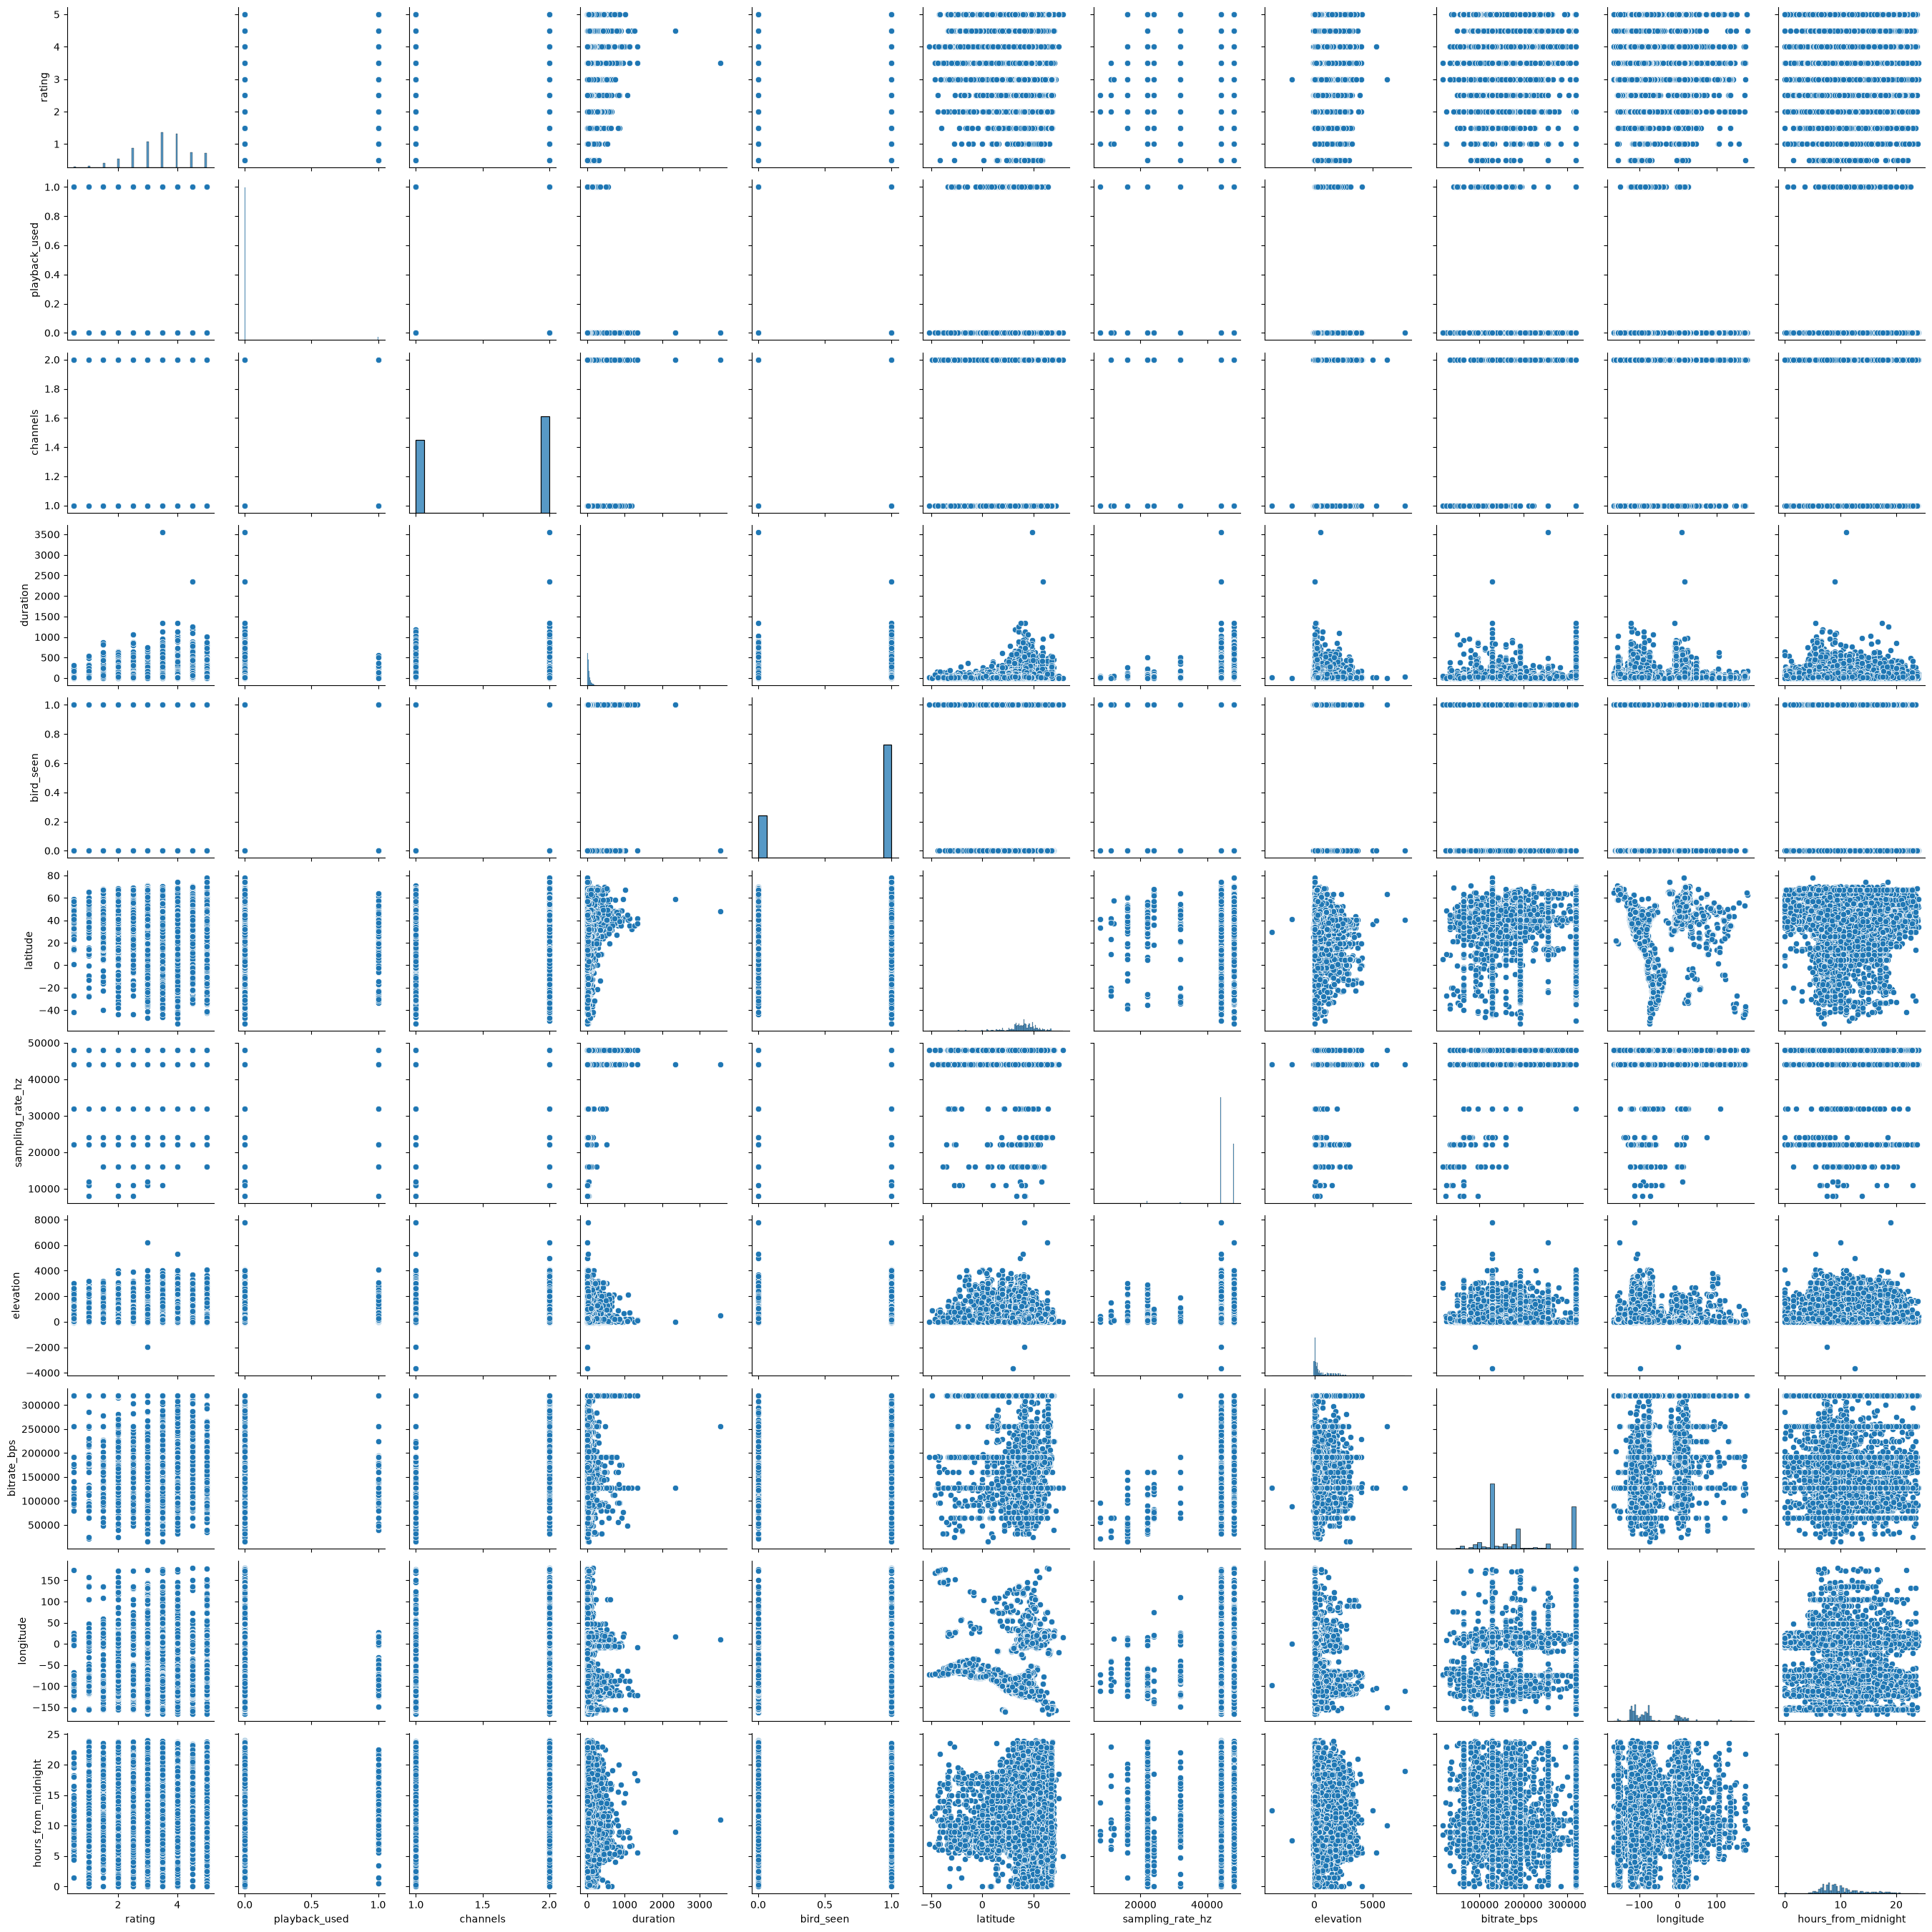

In [312]:
# doesn't actually show any patterns we can immediately discern because a majority of our features are strings
import seaborn as sns
sns.pairplot(data=drop_df)

array([[<Axes: title={'center': 'rating'}>,
        <Axes: title={'center': 'playback_used'}>,
        <Axes: title={'center': 'channels'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'bird_seen'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'sampling_rate_hz'}>,
        <Axes: title={'center': 'elevation'}>,
        <Axes: title={'center': 'bitrate_bps'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'hours_from_midnight'}>, <Axes: >]],
      dtype=object)

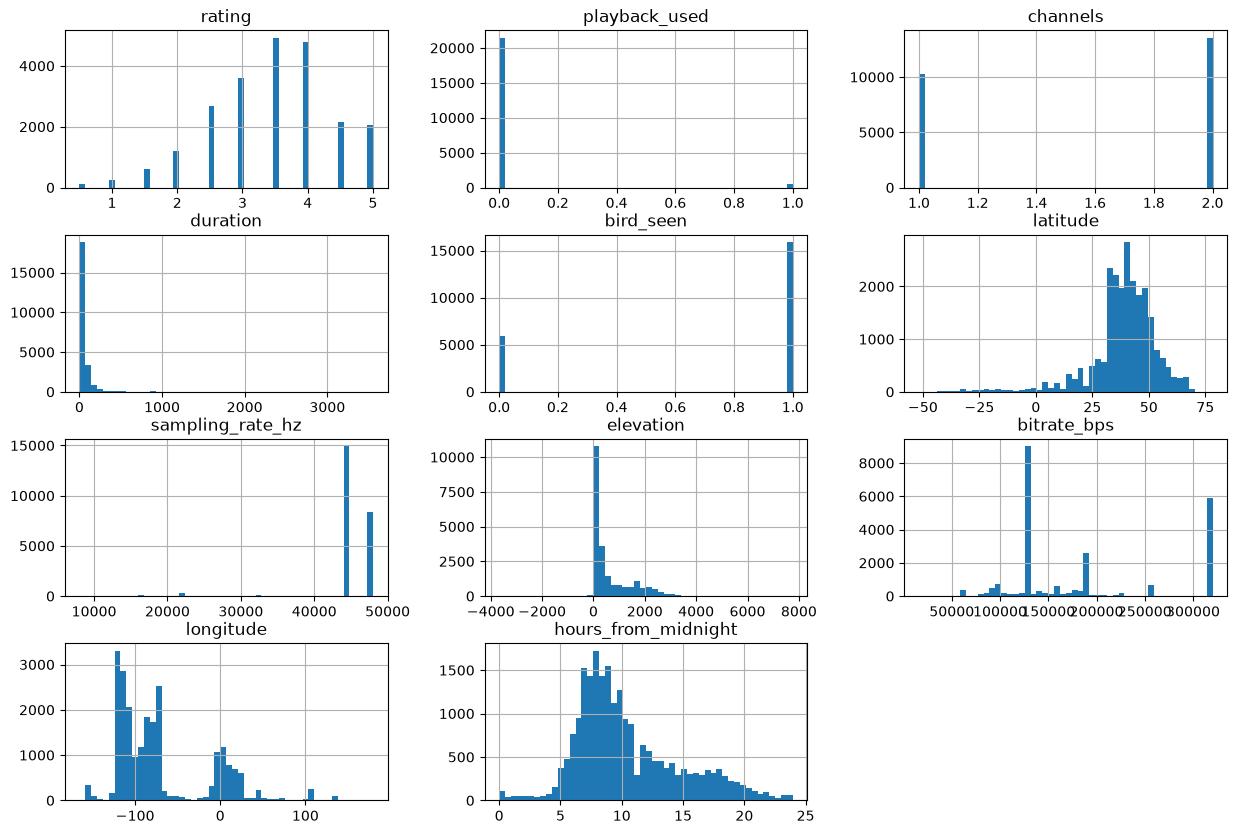

In [278]:
drop_df.hist(bins = 50, figsize=(15,10))

<Axes: xlabel='longitude', ylabel='latitude'>

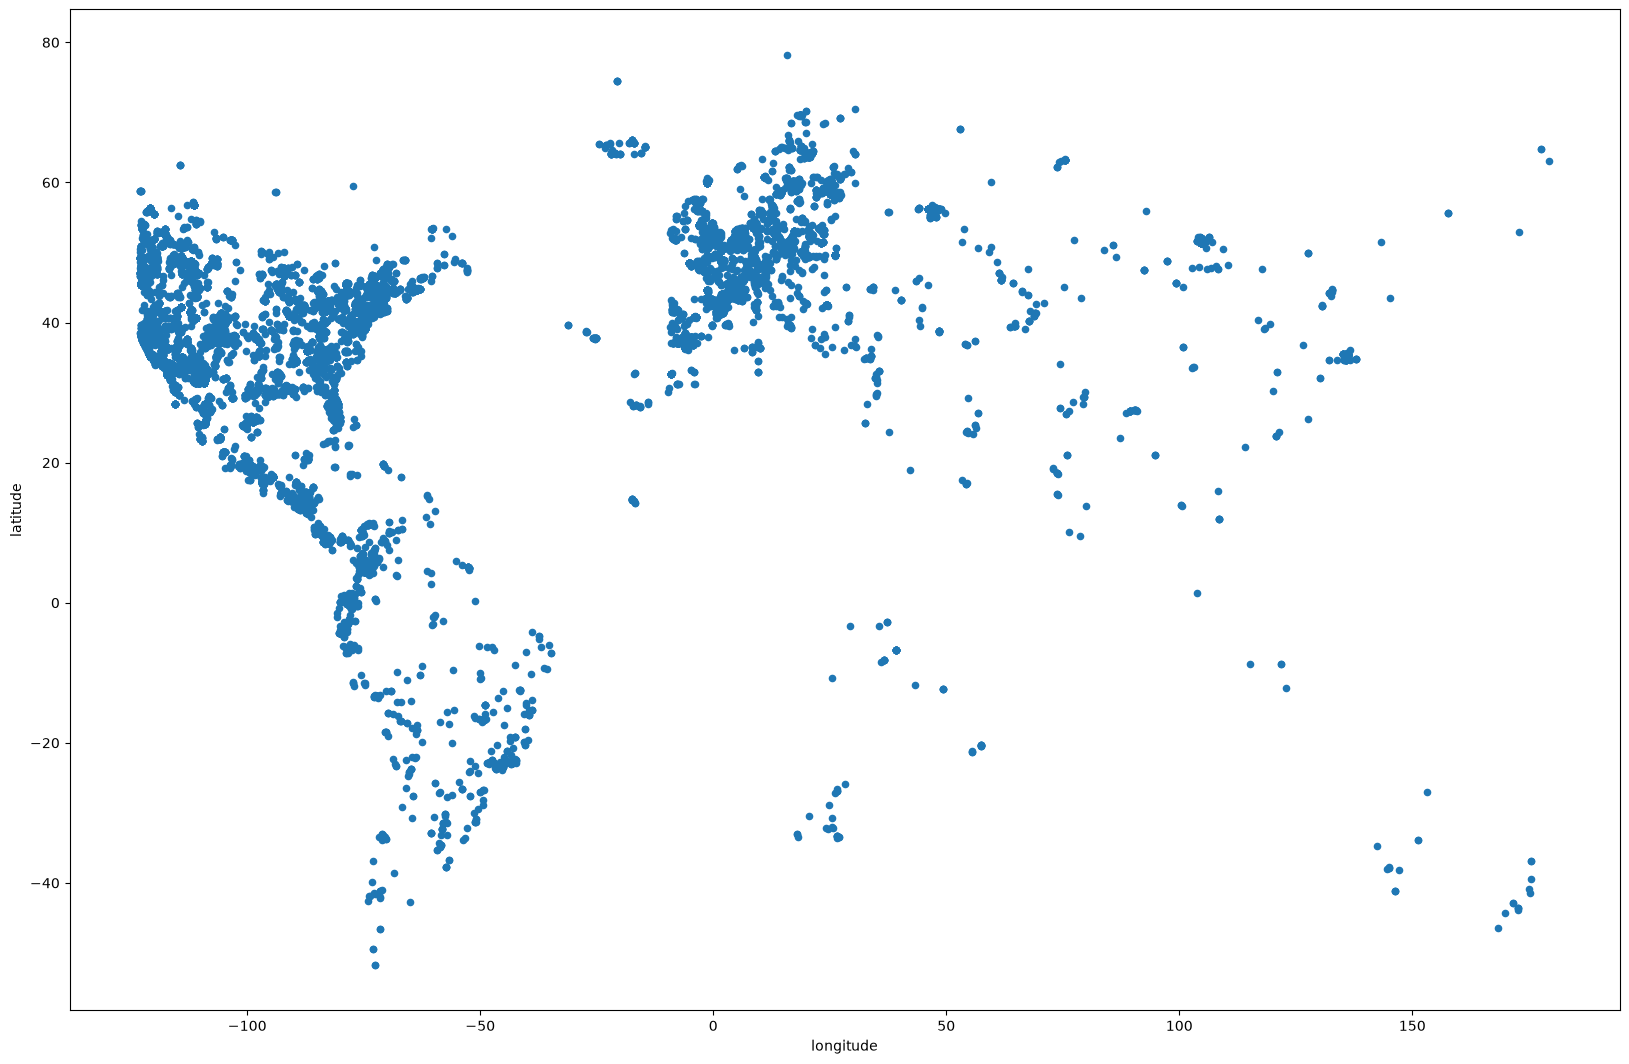

In [279]:
#our longitude and latitude map
drop_df[drop_df.longitude >- 123].plot(figsize=(20,13), kind='scatter', x='longitude', y='latitude')

<Axes: xlabel='longitude', ylabel='latitude'>

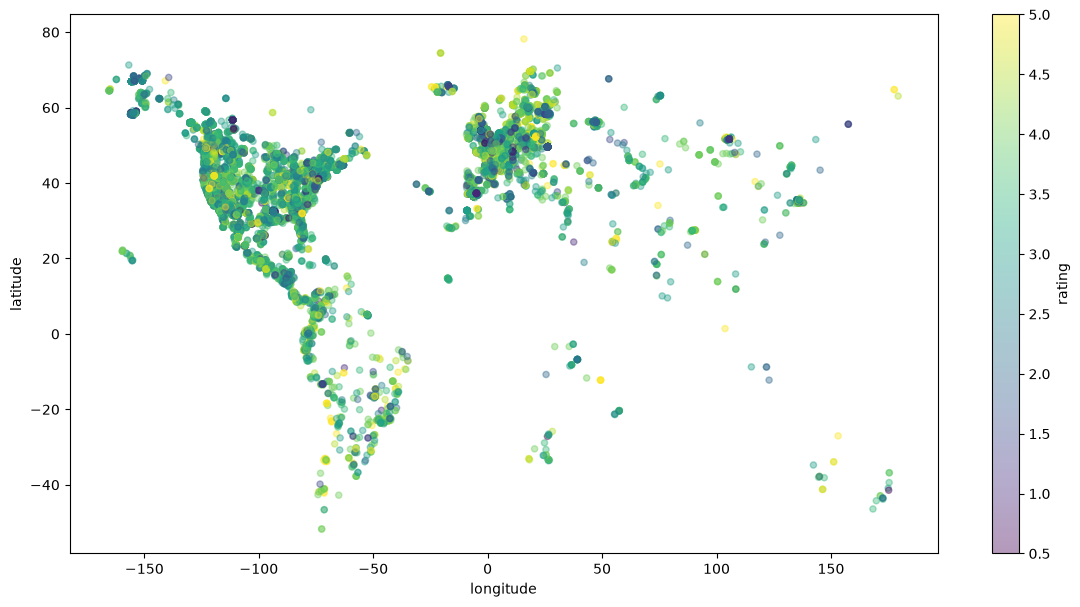

In [304]:
drop_df.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4, c='rating', figsize=(14, 7))

In [ ]:
drop_df.loc[(drop_df['rating'] > 4.5) & (drop_df['country'] == 'United States')]

,rating,playback_used,channels,date,duration,filename,species,secondary_labels,bird_seen,location,...,sampling_rate_hz,type,elevation,bitrate_bps,background,country,primary_label,longitude,hours_from_midnight,recordist
131,5.0,0,2,2016-07-11,10,XC587206.mp3,American Avocet,[],1,Bear River Migratory Bird Refuge (near Brigha...,...,44100,"adult, call, sex uncertain",1300.0,160000,NaN,United States,Recurvirostra americana_American Avocet,-112.1082,17.5,Craig Robertson
166,5.0,0,2,2020-07-12,44,XC575220.mp3,American Crow,[],1,"South end of Lakeview Rd, Bloomington, Hennepi...",...,44100,call,260.0,173371,NaN,United States,Corvus brachyrhynchos_American Crow,-93.3786,6.0,Michael Hurben
168,5.0,0,1,2020-06-29,5,XC572379.mp3,American Crow,[],0,"Hendrix Habitat - Fairview, Williamson County,...",...,24000,call,260.0,74632,NaN,United States,Corvus brachyrhynchos_American Crow,-87.1450,6.0,Brian Hendrix
169,5.0,0,2,2020-06-17,41,XC569711.mp3,American Crow,[],1,"Skidaway Island, Chatham County, GA USA",...,48000,call,0.0,125263,NaN,United States,Corvus brachyrhynchos_American Crow,-81.0559,15.0,Russ Wigh
171,5.0,0,1,2020-06-14,78,XC568365.mp3,American Crow,[],0,"Skidaway Island, Chatham County, GA USA",...,48000,"adult, call, sex uncertain",0.0,94777,NaN,United States,Corvus brachyrhynchos_American Crow,-81.0559,7.0,Russ Wigh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23638,5.0,0,1,2016-06-12,60,XC508002.mp3,Yellow-headed Blackbird,[],1,"Sierra Nevada (near Calpine), Sierra County, ...",...,48000,"adult, begging call, hatchling or nestling, se...",1500.0,256000,NaN,United States,Xanthocephalus xanthocephalus_Yellow-headed Bl...,-120.4325,8.0,Mike FitzGerald
23688,5.0,0,2,2020-04-27,39,XC551319.mp3,Myrtle Warbler,[],1,"Skidaway Island, Chatham County, GA USA",...,48000,song,5.0,138921,NaN,United States,Setophaga coronata_Myrtle Warbler,-81.0559,7.0,Russ Wigh
23776,5.0,0,2,2020-07-02,40,XC574089.mp3,Yellow-throated Vireo,[],1,"Brackettville, Kinney County, Texas",...,48000,"adult, sex uncertain, song",340.0,204187,NaN,United States,Vireo flavifrons_Yellow-throated Vireo,-100.4186,17.6,Phoenix Birder
23777,5.0,0,2,2020-06-06,33,XC565814.mp3,Yellow-throated Vireo,[],0,"Savannah, Chatham County, Georgia",...,48000,"adult, song",10.0,123487,NaN,United States,Vireo flavifrons_Yellow-throated Vireo,-81.0235,8.0,Russ Wigh


In [310]:
drop_df.loc[(drop_df['rating'] > 4.5) & (drop_df['country'] == 'United States')].describe()

,rating,playback_used,channels,duration,bird_seen,latitude,sampling_rate_hz,elevation,bitrate_bps,longitude,hours_from_midnight
count,927.0,909.0,927.0,927.000000,910.0,925.000000,927.0,924.000000,927.0,925.000000,923.000000
mean,5.0,0.020902,1.430421,59.642934,0.675824,38.052659,46145.954693,604.374686,168317.701187,-99.936936,9.466847
std,0.0,0.143135,0.495402,82.944143,0.468323,5.135644,4112.034875,771.914669,73614.946522,18.031767,4.011260
min,5.0,0.0,1.0,2.000000,0.0,25.428000,16000.0,-70.000000,35519.0,-165.405300,0.500000
25%,5.0,0.0,1.0,21.000000,0.0,33.411500,44100.0,30.000000,128000.0,-116.926800,7.000000
50%,5.0,0.0,1.0,39.000000,1.0,38.244300,48000.0,260.000000,130480.0,-105.072100,8.070000
75%,5.0,0.0,2.0,68.000000,1.0,41.257600,48000.0,1000.000000,192000.0,-82.956340,10.880000
max,5.0,1.0,2.0,1011.000000,1.0,64.503500,48000.0,3200.000000,320000.0,-67.861200,23.500000


In [280]:
# 0-0 indicates bird wasn't seen and a plyback wasn't used
# 0-1 bird wasn't seen and a playback was used
# 1-0 bird was seen and a playback wasn't used
# 1-1 bird was seen and  playback was used
pd.crosstab(drop_df["bird_seen"], drop_df["playback_used"], margins=True)

playback_used,0,1,All
bird_seen,,,
0,5698,68,5766
1,15059,399,15458
All,20757,467,21224


In [ ]:
print(drop_df['sampling_rate_hz'].describe())
drop_df['bitrate_bps'].describe()

count         23784.0
mean     44989.653759
std       3924.843675
min            8000.0
25%           44100.0
50%           44100.0
75%           48000.0
max           48000.0
Name: sampling_rate_hz, dtype: Float64


count          23784.0
mean     188018.613732
std       84024.236755
min            16000.0
25%           128000.0
50%           139479.0
75%           273119.5
max           320202.0
Name: bitrate_bps, dtype: Float64

In [300]:
# Spearman 
print("Spearman method - because we don't want the scale of the values to bury the possible correlations")
print(drop_df[["rating", "sampling_rate_hz", "bitrate_bps"]].corr(method="spearman")["rating"].drop("rating"))


print('---')

# Regular correlation from sep11
print("Normal Pearson (the default of df.corr())")
correlation = drop_df[["rating", "sampling_rate_hz", "bitrate_bps"]].corr()
print(correlation["rating"].drop("rating").sort_values(key=abs, ascending=False))

Spearman method - because we don't want the scale of the values to bury the possible correlations
sampling_rate_hz    0.181135
bitrate_bps         0.057782
Name: rating, dtype: float64
---
Normal Pearson (the default of df.corr())
sampling_rate_hz    0.130249
bitrate_bps         0.035647
Name: rating, dtype: float64
